# Problem Set 7: Attention

<span style="color:red">Warning!</span> Some of the later questions require model training. Start early, and make sure your code is correct on a small subset of the data before you train on the full dataset.

<span style="color:red">Note:</span> In this problem set, we will build up self-attention from first principles and then use it in a text classification problem. The goal is to build intuition for what attention is actually computing.

## SMS Spam: Attention for Text Classification

Your goal for this problem set is to build intuition for attention and then use it in a simple text classification problem. We will work with the [SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection), a binary classification dataset in which each text message is labeled as either **ham** (not spam) or **spam**.

We will proceed in two stages:

1. **Self-attention**: let each token attend to every other token.
2. **Modeling**: use attention inside a PyTorch classifier and compare it to a baseline.

From a coding perspective, it will be easiest to complete this problem set using **PyTorch**.

## Part I. Load the Data

### Question 1: Load data + exploratory analysis

For this problem, we will use the SMS Spam Collection dataset.

Your tasks:
1. Download and load the dataset.
2. Convert labels to integers (`ham -> 0`, `spam -> 1`).
3. Create train / test splits.
4. Inspect a few examples from each class.
5. Report the class balance.

You may keep preprocessing simple. Lowercasing and basic whitespace tokenization are enough for this assignment.

In [25]:
import math
import random
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 251
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [26]:
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)
DATA_PATH = DATA_DIR / "SMSSpamCollection"

if not DATA_PATH.exists():
    import urllib.request
    import zipfile

    url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
    zip_path = DATA_DIR / "sms_spam_collection.zip"
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)

# the file may be extracted into a subdirectory depending on the zip format
if not DATA_PATH.exists():
    candidate = DATA_DIR / "SMSSpamCollection"
    if candidate.exists():
        DATA_PATH = candidate
    else:
        candidate = DATA_DIR / "smsspamcollection" / "SMSSpamCollection"
        if candidate.exists():
            DATA_PATH = candidate

df = pd.read_csv(DATA_PATH, sep='	', header=None, names=['label', 'text'])
df['label_id'] = df['label'].map({'ham': 0, 'spam': 1})
print(df.shape)
df.head()

(5572, 3)


,label,text,label_id
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [27]:
idx = np.random.permutation(len(df))
train_end = int(0.80 * len(df))

train_df = df.iloc[idx[:train_end]].reset_index(drop=True)
test_df = df.iloc[idx[train_end:]].reset_index(drop=True)

print(len(train_df), len(test_df))

4457 1115


In [28]:
print("Class balance (full dataset):")
print(df['label'].value_counts(normalize=True))

print("Sample ham messages:")
for text in df[df.label == 'ham'].sample(3, random_state=SEED)['text']:
    print('-', text)

print("Sample spam messages:")
for text in df[df.label == 'spam'].sample(3, random_state=SEED)['text']:
    print('-', text)

Class balance (full dataset):
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64
Sample ham messages:
- Sure but since my parents will be working on Tuesday I don't really need a cover story
- Leaving to qatar tonite in search of an opportunity.all went fast.pls add me in ur prayers dear.Rakhesh
- If you are not coughing then its nothing
Sample spam messages:
- Urgent! call 09061749602 from Landline. Your complimentary 4* Tenerife Holiday or £10,000 cash await collection SAE T&Cs BOX 528 HP20 1YF 150ppm 18+
- YOU 07801543489 are guaranteed the latests Nokia Phone, a 40GB iPod MP3 player or a £500 prize! Txt word:COLLECT to No:83355! TC-LLC NY-USA 150p/Mt msgrcvd18+
- Our brand new mobile music service is now live. The free music player will arrive shortly. Just install on your phone to browse content from the top artists.


## Part II. Self-Attention

Now we move to **self-attention**. Self-attention produces a new representation for **every token**.

Given

$$
X \in \mathbb{R}^{n \times d_{\text{model}}},
$$

we compute

$$
Q = XW_Q, \qquad K = XW_K, \qquad V = XW_V.
$$

Then we compute pairwise scores

$$
S = QK^T,
$$

apply a row-wise softmax, and use the resulting weights to mix the value vectors.

**Questions 2–5** ask you to implement this step by step. To keep things simple, all functions in this part operate on **plain 2-D matrices** (`n_tokens × d`) — no batch dimension. You will use these building blocks conceptually in Question 11, but the full model there uses `nn.Linear` layers and handles batched input directly.

### Question 2: Compute Q, K, and V

Implement a function that computes `Q`, `K`, and `V`.

If `X` has shape `(n_tokens, d_model)` and each projection matrix has shape `(d_model, d_attn)`, then `Q`, `K`, and `V` should all have shape `(n_tokens, d_attn)`.

In [29]:
def compute_qkv(X, W_q, W_k, W_v):
    """
    X:   (n_tokens, d_model)
    W_q: (d_model, d_attn)
    W_k: (d_model, d_attn)
    W_v: (d_model, d_attn)

    returns: Q, K, V each with shape (n_tokens, d_attn)
    """
    Q = X @ W_q
    K = X @ W_k
    V = X @ W_v
    return Q, K, V

### Question 3: Pairwise attention scores

Implement a function that computes the matrix of pairwise scores:

$$
S = QK^T.
$$

If `Q` and `K` have shape `(n_tokens, d_attn)`, then `scores` should have shape `(n_tokens, n_tokens)`.

In [30]:
def self_attention_scores(Q, K):
    """
    Q: (n_tokens, d_attn)
    K: (n_tokens, d_attn)
    returns: scores of shape (n_tokens, n_tokens)
    """
    return Q @ K.T

### Question 4: Row-wise softmax

Implement a function that converts the score matrix into attention weights by applying a softmax over each row.

Each row should sum to 1. Row `i` tells you how token `i` distributes its attention across all tokens.

In [31]:
def row_softmax(scores):
    """
    scores: tensor of shape (n_tokens, n_tokens)
    returns: tensor of shape (n_tokens, n_tokens)
    """
    return torch.softmax(scores, dim=1)

### Question 5: Self-attention output

Implement a function that returns both the self-attention output and the attention weights.

You should:
1. compute `Q`, `K`, and `V`,
2. compute pairwise scores,
3. apply a row-wise softmax,
4. multiply the attention matrix by `V`.

The final output should have shape `(n_tokens, d_attn)`.

In [32]:
def self_attention(X, W_q, W_k, W_v):
    """
    X:   (n_tokens, d_model)
    W_q: (d_model, d_attn)
    W_k: (d_model, d_attn)
    W_v: (d_model, d_attn)

    returns:
        output:  (n_tokens, d_attn)
        weights: (n_tokens, n_tokens)
    """
    Q, K, V = compute_qkv(X, W_q, W_k, W_v)
    scores = self_attention_scores(Q, K)
    weights = row_softmax(scores)
    output = weights @ V
    return output, weights

In [33]:
# Simple check on a tiny example.
X_small = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
])
W_q = torch.eye(2)
W_k = torch.eye(2)
W_v = torch.eye(2)

out_small, weights_small = self_attention(X_small, W_q, W_k, W_v)
print(weights_small)
print(weights_small.sum(dim=1))
print(out_small)

tensor([[0.4223, 0.1554, 0.4223],
        [0.1554, 0.4223, 0.4223],
        [0.2119, 0.2119, 0.5761]])
tensor([1., 1., 1.])
tensor([[0.8446, 0.5777],
        [0.5777, 0.8446],
        [0.7881, 0.7881]])


### Question 6: A simple self-attention exercise

Use the tiny example above (`X_small`, `W_q`, `W_k`, `W_v`) and answer the following:

1. Which token does the **third token** attend to most strongly?
2. What happens to the attention weights if you replace the third token `[1, 1]` by `[0, 1]`?
3. Briefly explain your answer in terms of dot products.

A short written answer is sufficient.

In [34]:
X_variant = torch.tensor([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.0, 1.0],
])

_, weights_original = self_attention(X_small, W_q, W_k, W_v)
_, weights_variant = self_attention(X_variant, W_q, W_k, W_v)

print("Original attention from token 3:", weights_original[2])
print("Variant attention from token 3:", weights_variant[2])
print("In the original case, token 3 has equal dot product 1 with token 1 and token 2, and dot product 2 with itself.")
print("In the variant case, token 3 matches token 2 and itself more strongly than token 1.")

Original attention from token 3: tensor([0.2119, 0.2119, 0.5761])
Variant attention from token 3: tensor([0.1554, 0.4223, 0.4223])
In the original case, token 3 has equal dot product 1 with token 1 and token 2, and dot product 2 with itself.
In the variant case, token 3 matches token 2 and itself more strongly than token 1.


## Part III. Build Models for SMS Spam Classification

We will now use PyTorch modules to build and train two models:

1. a **baseline** model that embeds the tokens and averages them,
2. a **self-attention** model that applies one self-attention layer before classification.

To keep the assignment focused, we will use a simple whitespace tokenizer and a fixed maximum sequence length.

### Question 7: Tokenization, vocabulary, and dataloaders

In this question, you will build the full preprocessing pipeline that turns raw SMS messages into tensors that a PyTorch model can consume.

Keep the preprocessing simple. We will use:
1. lowercase whitespace tokenization,
2. an 80/20 train / test split,
3. a vocabulary built from the **training set only**,
4. fixed-length integer sequences,
5. PyTorch datasets and dataloaders.

Reserve index 0 for `<pad>` and index 1 for `<unk>`.

Use a fixed maximum sequence length:
$$
\text{MAX\_LEN} = 25.
$$

Work through the following substeps in order.

**Q7a. Tokenize one message**

Write a simple tokenizer that:
- lowercases the text,
- removes non-alphanumeric characters except apostrophes,
- splits on whitespace.

For example:
`"Free prize now!!!"` should become `["free", "prize", "now"]`.

In [35]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9']+", " ", text)
    return text.strip().split()

print(tokenize("Free prize now!!!"))

['free', 'prize', 'now']


**Q7b. Build a vocabulary from the training set**

Build a word counter using only the text in `train_df`.

Then create a vocabulary dictionary `vocab` with:
- `'<pad>' -> 0`
- `'<unk>' -> 1`

After that, add the most common words from the training set.

Store:
- `PAD_IDX`
- `UNK_IDX`

You may cap the vocabulary size at 5000.

In [36]:
counter = Counter()
for text in train_df['text']:
    counter.update(tokenize(text))

max_vocab_size = 5000
most_common = counter.most_common(max_vocab_size - 2)

vocab = {'<pad>': 0, '<unk>': 1}
for word, _ in most_common:
    vocab[word] = len(vocab)

PAD_IDX = vocab['<pad>']
UNK_IDX = vocab['<unk>']

print("vocab size =", len(vocab))
print("first few items:", list(vocab.items())[:10])

vocab size = 5000
first few items: [('<pad>', 0), ('<unk>', 1), ('i', 2), ('to', 3), ('you', 4), ('a', 5), ('the', 6), ('u', 7), ('and', 8), ('in', 9)]


**Q7c. Convert one message into token IDs**

Write an `encode` function that:
1. tokenizes the text,
2. replaces each token with its vocabulary ID,
3. uses `UNK_IDX` for unseen words,
4. truncates to `MAX_LEN`,
5. pads with `PAD_IDX` if the sequence is shorter than `MAX_LEN`.

The output should be a Python list of length `MAX_LEN`.

In [37]:
MAX_LEN = 25

def encode(text, vocab=vocab, max_len=MAX_LEN):
    ids = [vocab.get(tok, UNK_IDX) for tok in tokenize(text)]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids

example_ids = encode("Free prize now!!!")
print(example_ids)
print("length =", len(example_ids))

[48, 152, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
length = 25


**Q7d. Build a PyTorch `Dataset`**

Create a dataset class that stores:
- one tensor of token IDs for each message,
- one label for each message.

Each example returned by `__getitem__` should be:
`(text_tensor, label_tensor)`

where:
- `text_tensor` has shape `(MAX_LEN,)`
- `label_tensor` is a scalar tensor.

In [38]:
class SMSDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = [torch.tensor(encode(t), dtype=torch.long) for t in dataframe['text']]
        self.labels = [torch.tensor(y, dtype=torch.long) for y in dataframe['label_id']]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

**Q7e. Create train / test datasets and dataloaders**

Now create:
- `train_ds`, `test_ds`
- `train_loader`, `test_loader`

Use:
- `batch_size = 64`
- `shuffle=True` for training
- `shuffle=False` for testing

Finally, inspect one batch. If `batch_x` is the batch of token IDs, its shape should be:
$$
(\text{batch size}, \text{MAX\_LEN}).
$$

In [39]:
train_ds = SMSDataset(train_df)
test_ds = SMSDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

batch_x, batch_y = next(iter(train_loader))
print("batch_x shape:", batch_x.shape)
print("batch_y shape:", batch_y.shape)

batch_x shape: torch.Size([64, 25])
batch_y shape: torch.Size([64])


### Question 8: Baseline model

Implement a baseline classifier with the following structure:

1. embedding layer,
2. average pooling over non-padding tokens,
3. linear classifier.

This baseline treats all tokens equally after embedding.

In [40]:
class MeanPoolClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.classifier = nn.Linear(embed_dim, num_classes)
        self.pad_idx = pad_idx

    def forward(self, x):
        # x: (batch_size, seq_len)
        emb = self.embedding(x)
        mask = (x != self.pad_idx).float().unsqueeze(-1)
        summed = (emb * mask).sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1.0)
        pooled = summed / lengths
        logits = self.classifier(pooled)
        return logits

### Question 9: Training helpers

Write helper functions to train a model and to evaluate a model on a dataloader.

Report both loss and accuracy.

In [47]:
def training(model, n_epochs, optimizer, fn_loss, data_loader):
    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = fn_loss(outputs, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        print(f"Epoch {epoch}. Train loss {train_loss / len(data_loader):.4f}")

def validate(model, data_loader):
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        model.eval()
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = nn.CrossEntropyLoss()(outputs, y)
            _, predicted = torch.max(outputs, dim=1)

            total_loss += loss.item() * y.shape[0]
            total      += y.shape[0]
            correct    += int((predicted == y).sum())

    print(f"Loss:     {total_loss / total:.4f}")
    print(f"Accuracy: {correct / total:.2f}")

### Question 10: Train the baseline model

Train the baseline model and report test accuracy.

In [42]:
embed_dim = 64
baseline_model = MeanPoolClassifier(len(vocab), embed_dim, pad_idx=PAD_IDX).to(device)
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

training(baseline_model, n_epochs=10, optimizer=optimizer, fn_loss=criterion, data_loader=train_loader)

print("\nTest set performance:")
validate(baseline_model, test_loader)

Epoch 1. Train loss 0.6293
Epoch 2. Train loss 0.3969
Epoch 3. Train loss 0.2753
Epoch 4. Train loss 0.2074
Epoch 5. Train loss 0.1592
Epoch 6. Train loss 0.1256
Epoch 7. Train loss 0.1012
Epoch 8. Train loss 0.0841
Epoch 9. Train loss 0.0718
Epoch 10. Train loss 0.0625

Test set performance:
Loss:     0.0856
Accuracy: 0.97


### Question 11: A simple self-attention classifier

Implement a classifier with the following structure:

1. embedding layer (`nn.Embedding`),
2. linear projections to `Q`, `K`, and `V` — use **`nn.Linear` with `bias=False`** for each,
3. one self-attention layer,
4. average pooling over the contextualized token representations,
5. linear classifier (`nn.Linear`).

For simplicity, use **single-head self-attention**.

Note: the projection matrices here play the same role as $W_Q$, $W_K$, $W_V$ in Questions 2–5, but now they are `nn.Linear` layers that operate on batched 3-D tensors `(batch, seq_len, dim)`. Use `K.transpose(1, 2)` instead of `K.T` when computing the score matrix. Also apply **scaled dot-product attention**: divide the scores by $\sqrt{d_\text{attn}}$ before the softmax (this keeps the scores from growing large and stabilizes training).

You should mask out padding tokens so they do not receive attention and do not contribute to the pooled representation.

In [43]:
class SelfAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, attn_dim, num_classes=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.W_q = nn.Linear(embed_dim, attn_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, attn_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, attn_dim, bias=False)
        self.classifier = nn.Linear(attn_dim, num_classes)
        self.pad_idx = pad_idx
        self.scale = math.sqrt(attn_dim)

    def forward(self, x, return_attention=False):
        emb = self.embedding(x)                             # (B, T, D)
        Q = self.W_q(emb)                                   # (B, T, A)
        K = self.W_k(emb)                                   # (B, T, A)
        V = self.W_v(emb)                                   # (B, T, A)

        scores = Q @ K.transpose(1, 2) / self.scale         # (B, T, T)

        key_mask = (x != self.pad_idx).unsqueeze(1)         # (B, 1, T)
        scores = scores.masked_fill(~key_mask, -1e9)
        attn = torch.softmax(scores, dim=-1)                # (B, T, T)

        context = attn @ V                                  # (B, T, A)

        token_mask = (x != self.pad_idx).float().unsqueeze(-1)
        pooled = (context * token_mask).sum(dim=1) / token_mask.sum(dim=1).clamp(min=1.0)
        logits = self.classifier(pooled)

        if return_attention:
            return logits, attn
        return logits

### Question 12: Train the self-attention model

Train the self-attention model and compare its test accuracy to the baseline.

In [44]:
attn_model = SelfAttentionClassifier(len(vocab), embed_dim=64, attn_dim=64, pad_idx=PAD_IDX).to(device)
optimizer = torch.optim.Adam(attn_model.parameters(), lr=1e-3)

training(attn_model, n_epochs=10, optimizer=optimizer, fn_loss=criterion, data_loader=train_loader)

print("\nTest set performance:")
validate(attn_model, test_loader)

Epoch 1. Train loss 0.4146
Epoch 2. Train loss 0.1894
Epoch 3. Train loss 0.1203
Epoch 4. Train loss 0.0839
Epoch 5. Train loss 0.0591
Epoch 6. Train loss 0.0422
Epoch 7. Train loss 0.0293
Epoch 8. Train loss 0.0201
Epoch 9. Train loss 0.0132
Epoch 10. Train loss 0.0083

Test set performance:
Loss:     0.1422
Accuracy: 0.96


## Part IV. Compare and Interpret

### Question 13: Compare the models

Evaluate both models on the test set.

Then answer the following briefly:
1. Which model performs better?
2. Is the gap large or small?
3. Why might SMS spam still be a relatively easy dataset for the baseline?

In [45]:
print("Baseline performance:")
validate(baseline_model, test_loader)

print("\nSelf-attention performance:")
validate(attn_model, test_loader)

Baseline performance:
Loss:     0.0856
Accuracy: 0.97

Self-attention performance:
Loss:     0.1422
Accuracy: 0.96


### Question 14: Inspect an attention matrix

Pick a couple of SMS examples from the test set. Run it through the self-attention model and display the attention matrix as a heatmap.

Your tasks:
1. print the tokenized message,
2. show the attention matrix,
3. choose one row of the matrix and explain what it means.

Remember: row `i` tells you how token `i` distributes its attention across the sequence.

Yay can't wait to party together!
['yay', "can't", 'wait', 'to', 'party', 'together']


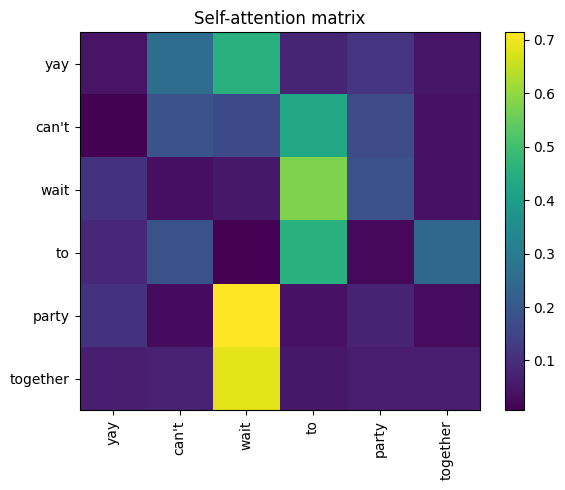

In [46]:
def decode_ids(ids, vocab):
    inv_vocab = {v:k for k,v in vocab.items()}
    return [inv_vocab.get(i, '<unk>') for i in ids if i != PAD_IDX]

sample_text = test_df.iloc[105]['text']
sample_ids = torch.tensor(encode(sample_text), dtype=torch.long).unsqueeze(0).to(device)
logits, attn = attn_model(sample_ids, return_attention=True)
attn = attn[0].detach().cpu()

tokens = decode_ids(sample_ids[0].cpu().tolist(), vocab)
T = len(tokens)
print(sample_text)
print(tokens)

plt.figure(figsize=(6, 5))
plt.imshow(attn[:T, :T], aspect='auto')
plt.xticks(range(T), tokens, rotation=90)
plt.yticks(range(T), tokens)
plt.title('Self-attention matrix')
plt.colorbar()
plt.tight_layout()
plt.show()